<h5> Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

<h11> display.max_columns prevents pandas from truncating output with 26 columns - you want to see everything. seaborn style is just for cleaner plots later.

<h5>  Load the dataset

In [3]:
df = pd.read_csv('dataset.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (24028, 27)


,ID,LIMIT_BAL,JOB_TYPE,WORK_YEARS,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,7303,390000.0,3.0,NaN,male,graduate school,single,34.0,-2.0,-2.0,-2.0,-1.0,-1.0,0.0,7639.0,10876.0,6203.0,1518.0,46365.0,48795.0,6083.0,1051.0,1545.0,47280.0,3000.0,3000.0,0
1,29777,290000.0,6.0,NaN,female,graduate school,married,33.0,0.0,0.0,0.0,0.0,0.0,0.0,277227.0,279189.0,265077.0,241284.0,102450.0,104544.0,10681.0,15089.0,8801.0,7450.0,4544.0,4028.0,0
2,27240,240000.0,11.0,NaN,female,graduate school,single,39.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,14719.0,3192.0,4389.0,10179.0,5413.0,1899.0,3192.0,4397.0,10179.0,5413.0,1899.0,21986.0,0
3,12937,220000.0,2.0,NaN,male,graduate school,single,32.0,1.0,2.0,2.0,2.0,2.0,2.0,202792.0,198157.0,211340.0,209612.0,219064.0,222672.0,0.0,16501.0,3200.0,13000.0,7500.0,0.0,0
4,8669,280000.0,5.0,9.0,male,university,married,35.0,0.0,0.0,0.0,0.0,0.0,0.0,184050.0,171714.0,154940.0,136894.0,138467.0,128473.0,7088.0,6107.0,5000.0,5057.0,5005.0,50012.0,0


<h11> First thing in any project - confirm the file loaded correctly and row/column counts match what you expect (should be 24,028 rows × 27 columns including target).

<h5> Data types and structure

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24028 entries, 0 to 24027
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          24028 non-null  int64  
 1   LIMIT_BAL                   23315 non-null  float64
 2   JOB_TYPE                    23348 non-null  float64
 3   WORK_YEARS                  3604 non-null   float64
 4   SEX                         23339 non-null  str    
 5   EDUCATION                   23374 non-null  str    
 6   MARRIAGE                    23314 non-null  str    
 7   AGE                         23331 non-null  float64
 8   PAY_0                       23322 non-null  float64
 9   PAY_2                       23327 non-null  float64
 10  PAY_3                       23350 non-null  float64
 11  PAY_4                       23328 non-null  float64
 12  PAY_5                       23321 non-null  float64
 13  PAY_6                       23336 non-null

<h11> This tells you dtype per column (float64, object, etc.) and non-null counts in one shot. Watch for:

Columns that should be numeric but are loaded as object (sign of stray characters or mixed types)
Columns with visibly low non-null counts (missing data red flags)

<h5>  Missing value audit

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
WORK_YEARS,20424,85.00
PAY_AMT2,736,3.06
MARRIAGE,714,2.97
LIMIT_BAL,713,2.97
PAY_AMT5,712,2.96
PAY_0,706,2.94
PAY_5,707,2.94
BILL_AMT2,707,2.94
PAY_2,701,2.92
PAY_4,700,2.91


<h11> Rather than eyeballing .info(), this gives you a clean sorted table of exactly which columns have missing data and how bad it is. This is the number that decides whether a column gets dropped, imputed, or bucketed as "UNKNOWN" — we'll make that call in the preprocessing notebook, but we need the evidence here first.

<h5> Target variable distribution

default payment next month
0    23364
1      664
Name: count, dtype: int64
default payment next month
0    97.236557
1     2.763443
Name: proportion, dtype: float64


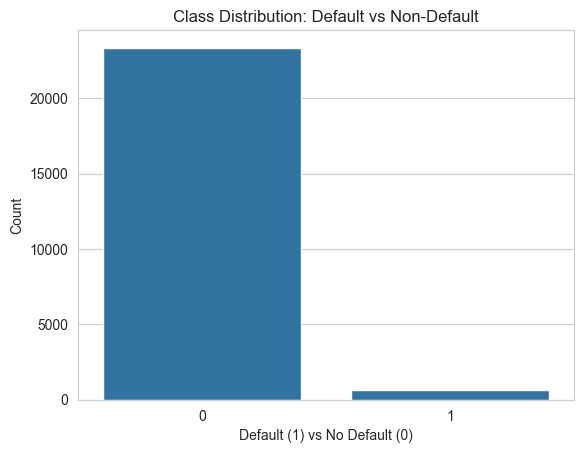

In [5]:
target_col = 'default payment next month'

target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct)

sns.countplot(x=target_col, data=df)
plt.title('Class Distribution: Default vs Non-Default')
plt.xlabel('Default (1) vs No Default (0)')
plt.ylabel('Count')
plt.show()

<h11> This is the single most important check in this notebook. It quantifies the imbalance problem you'll be dealing with for the rest of the project - you want the actual percentage from your run, not an assumed number.

<h5> Numeric feature summary

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ID,24028.0,15049.305310,8683.729582,3.0,7510.75,15061.0,22616.25,29997.0
LIMIT_BAL,23315.0,176513.060262,131408.979628,10000.0,60000.00,150000.0,250000.00,1000000.0
JOB_TYPE,23348.0,7.943978,4.319364,1.0,4.00,8.0,12.00,15.0
WORK_YEARS,3604.0,8.385405,3.381706,2.0,6.00,8.0,11.00,15.0
AGE,23331.0,35.420471,9.097404,21.0,28.00,34.0,41.00,79.0
PAY_0,23322.0,-0.184890,0.981034,-2.0,-1.00,0.0,0.00,8.0
PAY_2,23327.0,-0.279204,1.062574,-2.0,-1.00,0.0,0.00,8.0
PAY_3,23350.0,-0.298630,1.067764,-2.0,-1.00,0.0,0.00,8.0
PAY_4,23328.0,-0.337063,1.039798,-2.0,-1.00,0.0,0.00,8.0
PAY_5,23321.0,-0.372368,1.002363,-2.0,-1.00,0.0,0.00,7.0


<h11> .describe().T (transposed) is easier to scan for 20+ numeric columns. Look for: negative values in bill amounts (valid - means credit balance), suspicious min/max (e.g. AGE of 0 or 150), and scale differences between columns (relevant for scaling decisions later).

<h5> Categorical feature summary

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- SEX ---
SEX
male      14311
female     9028
NaN         689
Name: count, dtype: int64

--- EDUCATION ---
EDUCATION
university             10777
graduate school         8476
high school diploma     3697
NaN                      654
other                    308
post graduate            116
Name: count, dtype: int64

--- MARRIAGE ---
MARRIAGE
married    12558
single     10467
NaN          714
divorce      242
other         47
Name: count, dtype: int64


C:\Users\Sid\AppData\Local\Temp\ipykernel_26168\2974743562.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


<h11> For each categorical column, this shows every unique value including how many are missing (dropna=False). Watch for inconsistent labels (e.g. "male"/"Male"/"MALE" would show up as separate categories here) and unexpected categories.

<h5> JOB_TYPE breakdown + full numeric summary

In [8]:
print("JOB_TYPE unique values:")
print(df['JOB_TYPE'].value_counts(dropna=False).sort_index())

print("\nFull numeric summary:")
df[numeric_cols].describe().T

JOB_TYPE unique values:
JOB_TYPE
1.0     1638
2.0     1687
3.0     1628
4.0     1633
5.0     1619
6.0     1698
7.0     1716
8.0      230
9.0      839
10.0    1599
11.0    2256
12.0    2514
13.0    2217
14.0    1543
15.0     531
NaN      680
Name: count, dtype: int64

Full numeric summary:


,count,mean,std,min,25%,50%,75%,max
ID,24028.0,15049.305310,8683.729582,3.0,7510.75,15061.0,22616.25,29997.0
LIMIT_BAL,23315.0,176513.060262,131408.979628,10000.0,60000.00,150000.0,250000.00,1000000.0
JOB_TYPE,23348.0,7.943978,4.319364,1.0,4.00,8.0,12.00,15.0
WORK_YEARS,3604.0,8.385405,3.381706,2.0,6.00,8.0,11.00,15.0
AGE,23331.0,35.420471,9.097404,21.0,28.00,34.0,41.00,79.0
PAY_0,23322.0,-0.184890,0.981034,-2.0,-1.00,0.0,0.00,8.0
PAY_2,23327.0,-0.279204,1.062574,-2.0,-1.00,0.0,0.00,8.0
PAY_3,23350.0,-0.298630,1.067764,-2.0,-1.00,0.0,0.00,8.0
PAY_4,23328.0,-0.337063,1.039798,-2.0,-1.00,0.0,0.00,8.0
PAY_5,23321.0,-0.372368,1.002363,-2.0,-1.00,0.0,0.00,7.0


<h11>

-  JOB_TYPE showed up as numeric (1–11ish) in the describe output rather than a labeled category like EDUCATION or MARRIAGE. We need to see all its unique values to figure out whether it's actually a coded categorical (e.g. 1 = engineer, 2 = teacher, etc. - in which case it should eventually be treated as categorical, not a continuous number) or something else. sort_index() here just lays them out in order so it's easy to eyeball whether the codes are sequential (1 through 11) or have gaps.

- The describe().T in Cell 11 got cut off in your notebook display after PAY_AMT1 - re-running it here (or just scrolling the output) will show you PAY_AMT2 through PAY_AMT6, which we need to check for the same negative-value or outlier patterns we saw in the bill amounts.

<h11>

Quick recap of what we've built and locked in:
- Loaded raw dataset.csv, confirmed shape (24,028 rows × 27 columns)
- Checked dtypes and structure via .info() — all numerics correctly typed, categoricals (SEX, EDUCATION, MARRIAGE) as string/object
- Audited missing values across all columns — WORK_YEARS flagged at 85% missing (drop candidate), everything else clustered at ~2.7–3.1%, suggesting uniformly random missingness
- Confirmed severe target imbalance: 97.24% no-default vs 2.76% default
- Reviewed numeric summary stats — flagged genuine negative values in BILL_AMT1–6 (credit balances, not errors) and extreme right-skew in PAY_AMT1–6
- Reviewed categorical value counts — SEX, EDUCATION, MARRIAGE all clean, no inconsistent labels
- Investigated JOB_TYPE separately — found 15 unlabeled numeric codes with no natural order, flagging it for one-hot encoding rather than raw numeric treatment
- No cleaning or transformations applied yet — this notebook is pure exploration, setting up informed decisions for later notebooks